# Create Raster Data

To create raster data, you need to supply the following: 

1. A spatial reference system (srs)
2. Bounds in the units of the srs
   1. Either as Tuple with (xmin, ymin, xmax, ymax)
   2. Or using an Extent object
3. The pixelWidth as a number in the units of the provided spatial reference system (SRS).
4. The pixelHeight as a number in the units of the provided spatial reference system (SRS).
5. A data matrix incorporating values for each pixel


It is important that the bounds, pixelWidth and pixelHeight are chosen appropriately to each other. The pixel rows and columns are calculated by

- pixelColumns = (x_max - x_min) / pixelWidth
- pixelRows = (y_max - y_min) /pixelHeight

The shape of the provided data matrix must match the number of pixel rows and columns.

In [1]:
import geokit.core.raster
import numpy as np
import matplotlib.pyplot as plt

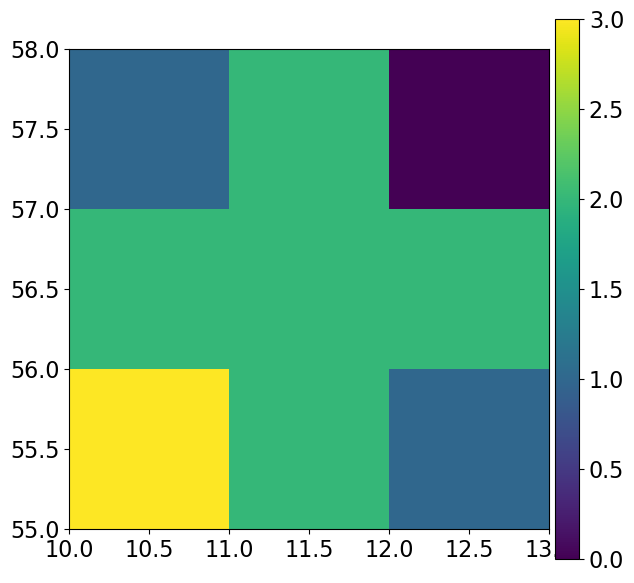

In [ ]:
raster_matrix_3x3 = np.array(
    [
        [1, 2, 0],
        [2, 2, 2],
        [3, 2, 1],
    ]
)

raster_in_memory = geokit.core.raster.createRaster(
    bounds=(10, 55, 13, 58),
    pixelWidth=1,
    pixelHeight=1,
    data=raster_matrix_3x3,
    srs=4326,
)

axh = geokit.core.raster.drawRaster(raster_in_memory, figsize=(6, 6))
plt.show()

# Save the Raster as a GeoTIFF File

The previous raster was only created in memory as a GDAL Dataset object. To save it as a .tif file to your hard drive, provide a path to the createRaster function. The function writes the file to the specified path and returns the path as a string, making it easy to further process the newly created file.

In [3]:
import pathlib

current_directory = pathlib.Path.cwd()
path_to_output_file = current_directory.joinpath("3x3_test_raster.tif")

raster_path = geokit.core.raster.createRaster(
    bounds=(10, 55, 13, 58),
    pixelWidth=1,
    pixelHeight=1,
    data=raster_matrix_3x3,
    srs=4326,
    output=str(path_to_output_file),
    overwrite=True,
)

print(raster_path)

/fast/home/d-marmullaku/Projects/Hackathon_2/geokit/Examples/_01_raster/3x3_test_raster.tif


# Accepted data types:

Rasters can be created from:

- positive floats
- negative floats
- Not a Number (NaN) values
- Booleans (True or False)
- integers including Zeroes

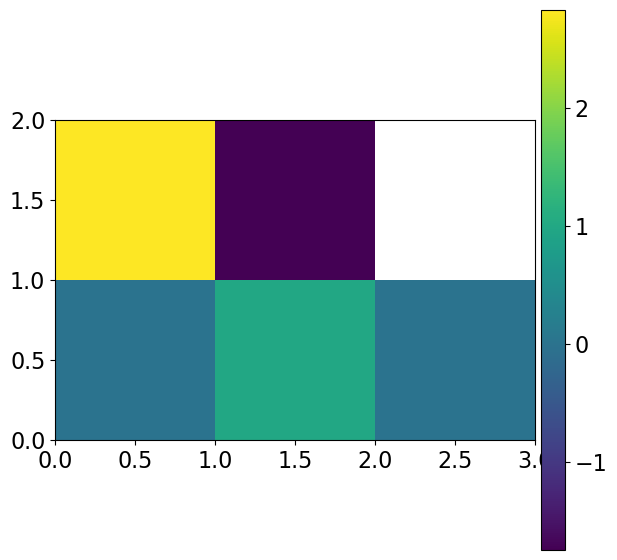

In [4]:
raster_matrix_2x3 = np.array(
    [
        [2.834, -1.75, np.nan],
        [False, True, 0],
    ]
)

ras = geokit.core.raster.createRaster(
    bounds=(0, 0, 3, 2),
    pixelWidth=1,
    pixelHeight=1,
    data=raster_matrix_2x3,
    srs=4326,
)
axh = geokit.core.raster.drawRaster(source=ras, figsize=(6, 6))
plt.show()

# Fast Creation of Homogeneous Raster

drawRaster also provides shortcuts for simple creation of homogeneous rasters.

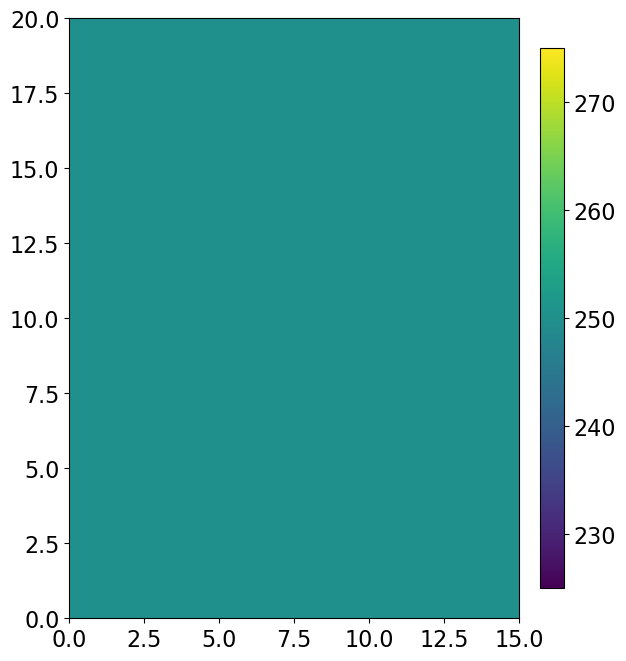

In [5]:
homogeneous_raster = geokit.core.raster.createRaster(
    bounds=(0, 0, 15, 20),
    pixelWidth=1,
    pixelHeight=1,
    fill=250,
    srs=4236,
)
axh = geokit.core.raster.drawRaster(source=homogeneous_raster, figsize=(6, 6))
plt.show()

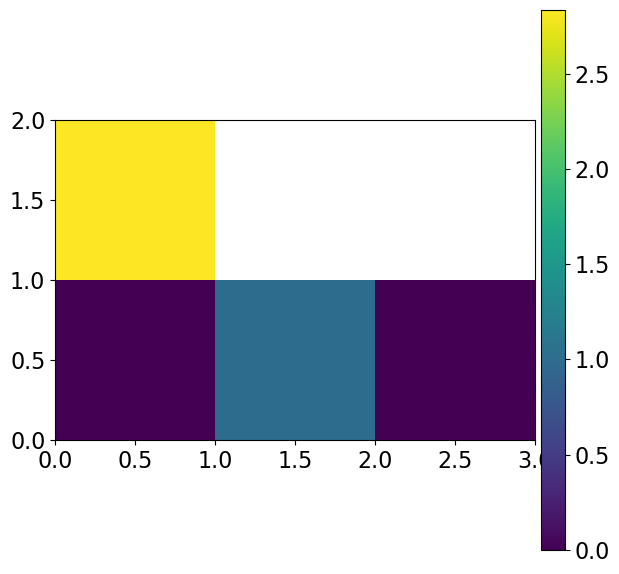

In [6]:
import numpy as np
import geokit as gk

raster_matrix_2x3 = np.array(
    [
        [2.834, 255, np.nan],
        [False, True, 0],
    ]
)

ras = geokit.core.raster.createRaster(
    bounds=(0, 0, 3, 2),
    pixelWidth=1,
    pixelHeight=1,
    data=raster_matrix_2x3,
    srs=4326,
    noData=255,
    # output=intermediate_raster_tif_str,
)

axes_handle = gk.drawRaster(ras, figsize=(6, 6), srs=4326)